In [1]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib_inline.backend_inline import set_matplotlib_formats
from matplotlib.ticker import MaxNLocator

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (
        candidate
        for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
        if (candidate / "modules").is_dir() and (candidate / "pipelines").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repository root from the current working directory")

SCENARIO_DIR = CURRENT_DIR
if not (SCENARIO_DIR / "contact_plan_2.json").exists():
    scenario_candidate = REPO_ROOT / "scenarios" / "wisee_four_planes_polar"
    if not scenario_candidate.exists():
        raise RuntimeError("Could not locate the scenario directory wisee_four_planes_polar")
    SCENARIO_DIR = scenario_candidate

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from models.model1_max_routes import (
    plot_selected_routes_vs_keys,
    solve_for_security_model as solve_m1_for_security_model,
)
from models.model2_min_keys import (
    plot_connectivity_pair_coverage_heatmap,
    plot_selected_keys_vs_connectivity,
    solve_for_security_model as solve_m2_for_security_model,
)
from models.model3_min_keys_full_connectivity import (
    plot_selected_keys_by_model,
    plot_selected_routes_by_model,
    solve_for_security_model as solve_m3_for_security_model,
)
from models.model4_max_connectivity_under_budget import (
    plot_budget_pair_coverage_heatmap,
    plot_connectivity_vs_budget,
    solve_for_security_model as solve_m4_for_security_model,
)
from modules.network.temporal_graph import plot_temporal_graph
from models.plot_utils import (
    MODEL_DISPLAY_ORDER,
    MODEL_PALETTE,
    auxiliary_cmap,
    format_model_label,
    format_model_series,
    palette_for,
    plot_metric_bars_by_model,
    secondary_palette,
    set_plot_theme,
)
from modules.security.models import KeyType, SecurityModelType
from pipelines.route_activation import RouteActivationPlanner
from pipelines.routing import CGRYenRouting
from pipelines.simulation import SimulationPipeline

set_plot_theme()
set_matplotlib_formats("svg")

PAPER_FIG_DIR = REPO_ROOT / "new_WISEE_2026_DTN_Security_Schemes_Optimization" / "5_analysis"
PAPER_FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_paper_figure(fig, stem: str, paper_dir:str=PAPER_FIG_DIR) -> None:
    fig.savefig(paper_dir / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(paper_dir / f"{stem}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# Four planes polar scenario

/Users/ramirodetke/.pyenv/versions/bpsec-keys/lib/python3.13/site-packages/teneto/neuroimagingtools/fmriutils.py:6: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiLabelsMasker


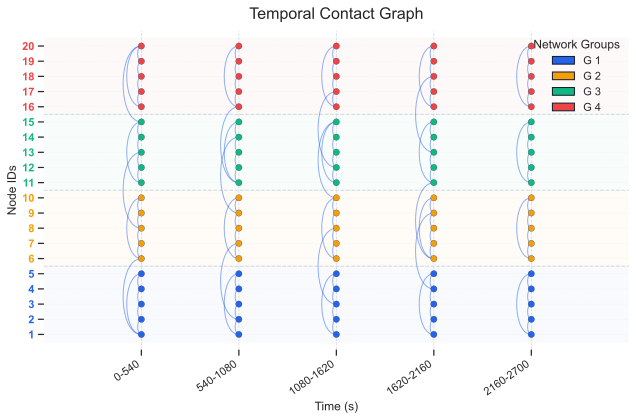

In [2]:
set_plot_theme()

contact_plan = json.loads((SCENARIO_DIR / "contact_plan_2.json").read_text())
topology = json.loads((SCENARIO_DIR / "topology.json").read_text())

fig, ax = plot_temporal_graph(
    contact_plan=contact_plan,
    topology=topology,
    title="Temporal Contact Graph",
    network_label_prefix="G",
    figsize=(9,6),
    nodesize=40,
)
plt.show()


In [3]:
max_routes = 3
pipeline = SimulationPipeline()

result = pipeline.run(
    cp_path=str(SCENARIO_DIR / "contact_plan_2.json"),
    topology_path=str(SCENARIO_DIR / "topology.json"),
    security_models=tuple(SecurityModelType),
    curr_time=0,
    routing_algorithm=CGRYenRouting(max_routes=max_routes),
)


In [4]:
set_plot_theme()

SERIES_COLORS = {
    model: MODEL_PALETTE[format_model_label(model)]
    for model in SecurityModelType
}
KEY_TYPE_ORDER = ["N-N", "N-G", "G-G", "Total"]
KEY_TYPE_PALETTE = secondary_palette(KEY_TYPE_ORDER)
ROUTE_HEATMAP_CMAP = auxiliary_cmap("routes")


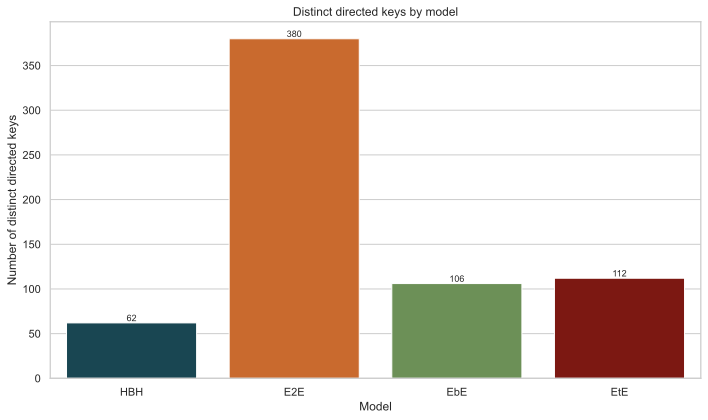

In [5]:
planner = RouteActivationPlanner()

rows = []
for model in SecurityModelType:
    planning = planner.build_for_model(result.security, model=model)
    rows.append(
        {
            "model": model,
            "unique_keys": len(planning.key_scopes),
        }
    )

df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 6))
plot_metric_bars_by_model(
    df,
    y="unique_keys",
    ax=ax,
    y_label="Number of distinct directed keys",
    title="Distinct directed keys by model",
)

plt.tight_layout()
plt.show()


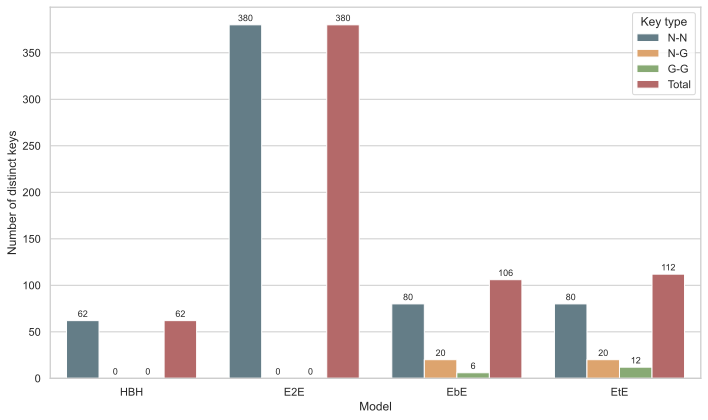

In [6]:
planner = RouteActivationPlanner()

rows = []
for model in SecurityModelType:
    planning = planner.build_for_model(result.security, model=model)
    key_scopes = planning.key_scopes

    counts = {
        "N-N": sum(1 for scope in key_scopes if scope.key_type == KeyType.NODE_TO_NODE),
        "N-G": sum(1 for scope in key_scopes if scope.key_type == KeyType.NODE_TO_GROUP),
        "G-G": sum(1 for scope in key_scopes if scope.key_type == KeyType.GROUP_TO_GROUP),
    }
    counts["Total"] = len(key_scopes)

    for key_type_label in KEY_TYPE_ORDER:
        rows.append(
            {
                "model": model,
                "key_type": key_type_label,
                "count": counts[key_type_label],
            }
        )

df = pd.DataFrame(rows)
df["model"] = format_model_series(df["model"])

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df,
    x="model",
    y="count",
    hue="key_type",
    order=MODEL_DISPLAY_ORDER,
    hue_order=KEY_TYPE_ORDER,
    palette=KEY_TYPE_PALETTE,
)

ax.set_ylabel("Number of distinct keys")
ax.set_xlabel("Model")
ax.legend(title="Key type")

for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=9)

plt.tight_layout()
plt.show()


In [7]:
def unique_scopes_by_model(sim_result, model_type):
    return {
        req.scope
        for pair in sim_result.security.pairs
        for plan in sim_result.security.plans_by_model[model_type][pair]
        for req in plan.key_requirements
    }


def format_scope(scope):
    return f"G{scope.source_id}->G{scope.target_id}"


ebe_label = format_model_label(SecurityModelType.EDGE_BY_EDGE)
ete_label = format_model_label(SecurityModelType.EDGE_TO_EDGE)

ebe_scopes = unique_scopes_by_model(result, SecurityModelType.EDGE_BY_EDGE)
ete_scopes = unique_scopes_by_model(result, SecurityModelType.EDGE_TO_EDGE)

ebe_gg = {
    scope for scope in ebe_scopes if scope.key_type == KeyType.GROUP_TO_GROUP
}
ete_gg = {
    scope for scope in ete_scopes if scope.key_type == KeyType.GROUP_TO_GROUP
}

summary_df = pd.DataFrame(
    [
        {"Model": ebe_label, "Unique G-G": len(ebe_gg)},
        {"Model": ete_label, "Unique G-G": len(ete_gg)},
    ]
)

all_gg = sorted(
    ebe_gg | ete_gg,
    key=lambda scope: (scope.source_id, scope.target_id),
)

comparison_df = pd.DataFrame(
    {
        "Scope": [format_scope(scope) for scope in all_gg],
        ebe_label: [format_scope(scope) if scope in ebe_gg else "" for scope in all_gg],
        ete_label: [format_scope(scope) if scope in ete_gg else "" for scope in all_gg],
    }
)

display(summary_df)
display(comparison_df)


,Model,Unique G-G
0,EbE,6
1,EtE,12


,Scope,EbE,EtE
0,G1->G2,G1->G2,G1->G2
1,G1->G3,,G1->G3
2,G1->G4,,G1->G4
3,G2->G1,G2->G1,G2->G1
4,G2->G3,G2->G3,G2->G3
5,G2->G4,,G2->G4
6,G3->G1,,G3->G1
7,G3->G2,G3->G2,G3->G2
8,G3->G4,G3->G4,G3->G4
9,G4->G1,,G4->G1


## Edge by Edge Group to Group unique key scopes
```mermaid
graph LR
    G1["G1"]
    G2["G2"]
    G3["G3"]
    G4["G4"]

    G1 --> G2
    G2 --> G1
    G2 --> G3
    G3 --> G2
    G3 --> G4
    G4 --> G3

```
## Edge by Edge Group to Group unique key scopes
* Dashed line arrows represent distinct key scopes used by edge-to-edge
* Continous line arrows represent shared key scopes between edge-to-edge and edge-by-edge
```mermaid
graph LR
    G1["G1"]
    G2["G2"]
    G3["G3"]
    G4["G4"]

    G1 --> G2
    G2 --> G1
    G2 --> G3
    G3 --> G2
    G3 --> G4
    G4 --> G3

    G1 -.-> G3
    G1 -.-> G4
    G2 -.-> G4
    G3 -.-> G1
    G4 -.-> G1
    G4 -.-> G2

```

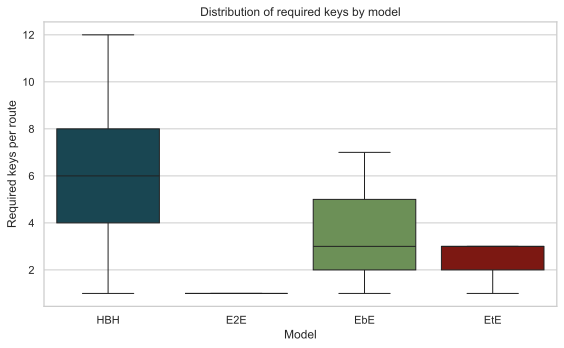

In [8]:
rows = []

for model, plans_by_pair in result.security.plans_by_model.items():
    for pair, plans in plans_by_pair.items():
        for plan in plans:
            unique_scopes = {req.scope for req in plan.key_requirements}
            rows.append(
                {
                    "model": format_model_label(model),
                    "pair": f"{pair[0]}->{pair[1]}",
                    "route": f"{pair[0]}->{pair[1]}:{plan.route_id}",
                    "required_keys": len(unique_scopes),
                }
            )

df_keys = pd.DataFrame(rows)
df_keys["model"] = format_model_series(df_keys["model"])

plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    data=df_keys,
    x="model",
    y="required_keys",
    hue="model",
    order=MODEL_DISPLAY_ORDER,
    hue_order=MODEL_DISPLAY_ORDER,
    dodge=False,
    palette=palette_for(df_keys["model"]),
    legend=False,
)
ax.set_title("Distribution of required keys by model")
ax.set_xlabel("Model")
ax.set_ylabel("Required keys per route")

plt.tight_layout()
plt.show()


## **(WiSEE)** Minimize keys for a pair-connectivity target 

<table>
<tr>
<td style="width:50%; border:none; vertical-align:top;">

#### Notation
$$
\begin{aligned}
D &: \text{set of evaluated ordered source-destination pairs} \\
P_{sd} &: \text{set of candidate routes for pair } (s,d) \in D \\
P &= \bigcup_{(s,d) \in D} P_{sd} \\
K &: \text{global set of activatable key scopes} \\
K(p) &\subseteq K : \text{key scopes required by route } p \in P \\
\gamma &: \text{target connectivity fraction}
\end{aligned}
$$

$$
\begin{aligned}
x_{sd} &=
\begin{cases}
1 & \text{if pair } (s,d) \text{ is connected} \\
0 & \text{otherwise}
\end{cases}
\\[4pt]
y_p &=
\begin{cases}
1 & \text{if route } p \text{ is activated} \\
0 & \text{otherwise}
\end{cases}
\\[4pt]
z_k &=
\begin{cases}
1 & \text{if key scope } k \text{ is activated} \\
0 & \text{otherwise}
\end{cases}
\end{aligned}
$$

</td>
<td style="width:50%; border:none; vertical-align:top;">

#### Model
$$
\begin{aligned}
\min \quad & \sum_{k \in K} z_k \\
\text{s.t.} \quad
& \sum_{(s,d) \in D} x_{sd} \ge \left\lceil \gamma |D| \right\rceil \\
& y_p \le x_{sd} \qquad \forall (s,d) \in D,\ \forall p \in P_{sd} \\
& x_{sd} \le \sum_{p \in P_{sd}} y_p \qquad \forall (s,d) \in D \\
& \sum_{k \in K(p)} z_k \ge |K(p)|\,y_p \qquad \forall p \in P \\
& x_{sd} \in \{0,1\} \qquad \forall (s,d) \in D \\
& y_p \in \{0,1\} \qquad \forall p \in P \\
& z_k \in \{0,1\} \qquad \forall k \in K
\end{aligned}
$$

</td>
</tr>
</table>


In [9]:
df_m2 = pd.DataFrame()
traces_m2 = {}

for sec_model in SERIES_COLORS.keys():
    print(f"Running for {sec_model.name}")

    sec_traces, sec_df = solve_m2_for_security_model(result, sec_model)
    traces_m2[sec_model.name] = dict(zip(sec_df["target_connectivity_pct"], sec_traces))
    df_m2 = pd.concat([df_m2, sec_df], ignore_index=True)


Running for HOP_BY_HOP
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2821306
Academic license 2821306 - for non-commercial use only - registered to ra___@unc.edu.ar
Running for END_TO_END
Running for EDGE_BY_EDGE
Running for EDGE_TO_EDGE


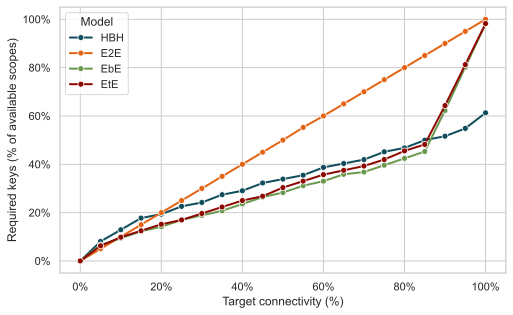

In [10]:
# WiSEE plot
from models.plot_utils import plot_metric_curve

planner = RouteActivationPlanner()
total_scopes_by_model = {
    model.name: len(planner.build_for_model(result.security, model=model).key_scopes)
    for model in SecurityModelType
}

df_m2_paper = df_m2.copy()
df_m2_paper["total_key_scopes"] = df_m2_paper["model"].map(total_scopes_by_model)
df_m2_paper["selected_keys_pct_of_available"] = (
    100.0 * df_m2_paper["selected_keys"] / df_m2_paper["total_key_scopes"]
)
df_m2_paper["model"] = format_model_series(df_m2_paper["model"])

set_plot_theme()
fig, ax = plt.subplots(figsize=(8, 4.8))

plot_metric_curve(
    df_m2_paper,
    x="target_connectivity_pct",
    y="selected_keys_pct_of_available",
    ax=ax,
    sort_by="target_connectivity_pct",
    palette=palette_for(df_m2_paper["model"]),
    x_percent_scale=100,
    y_percent_scale=100,
    x_label="Target connectivity (%)",
    y_label="Required keys (% of available scopes)",
    # title="Required key share vs target connectivity",
)

save_paper_figure(fig, "model2_fpp_required_key_share_vs_connectivity")


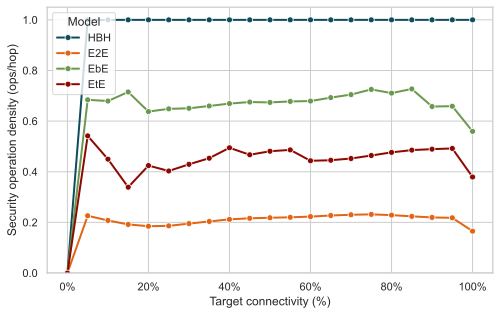

In [11]:
# WiSEE plot
rows = []

for model_name, traces_by_target in traces_m2.items():
    for target_connectivity_pct, trace in traces_by_target.items():
        if trace is None or not trace.routes:
            rows.append(
                {
                    "model": model_name,
                    "target_connectivity_pct": target_connectivity_pct,
                    "selected_routes": 0,
                    "hop_weighted_security_operation_density_per_hop": 0.0,
                }
            )
            continue

        total_operations = sum(
            len(route.operations)
            for route in trace.routes
            if route.contacts
        )
        total_hops = sum(
            len(route.contacts)
            for route in trace.routes
            if route.contacts
        )

        rows.append(
            {
                "model": model_name,
                "target_connectivity_pct": target_connectivity_pct,
                "selected_routes": len(trace.routes),
                # Hop-weighted normalization: sum ops(r) / sum hops(r)
                # across the selected routes for the connectivity target.
                "hop_weighted_security_operation_density_per_hop": (
                    total_operations / total_hops if total_hops else 0.0
                ),
            }
        )

df_m2_route_ops_hop_weighted = pd.DataFrame(rows)
df_m2_route_ops_hop_weighted["model"] = format_model_series(
    df_m2_route_ops_hop_weighted["model"]
)

set_plot_theme()
fig, ax = plt.subplots(figsize=(8, 4.8))

plot_metric_curve(
    df_m2_route_ops_hop_weighted,
    x="target_connectivity_pct",
    y="hop_weighted_security_operation_density_per_hop",
    ax=ax,
    sort_by="target_connectivity_pct",
    palette=palette_for(df_m2_route_ops_hop_weighted["model"]),
    x_percent_scale=100,
    x_label="Target connectivity (%)",
    y_label="Security operation density (ops/hop)",
    # title="Hop-weighted security operations vs target connectivity",
)

ax.set_ylim(0, 1.05)

save_paper_figure(fig, "model2_fpp_security_op_density_vs_connectivity")


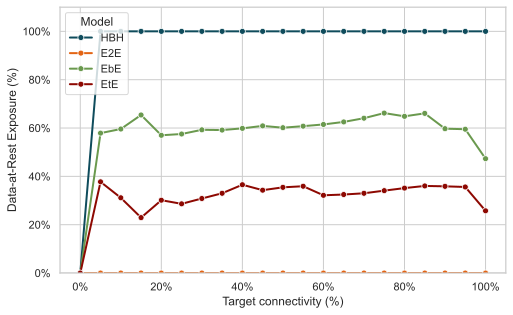

In [12]:
rows = []
for model_name, traces_by_target in traces_m2.items():
    for target_connectivity_pct, trace in traces_by_target.items():
        if trace is None or not trace.routes:
            rows.append(
                {
                    "model": model_name,
                    "target_connectivity_pct": target_connectivity_pct,
                    "selected_routes": 0,
                    "security_operation_density_per_hop": 0.0,
                }
            )
            continue
        
        total_nodes_per_route = [len(route.node_path)-2 for route in trace.routes]
        active_per_route = []
        
        for route in trace.routes:
            active_nodes_in_route = {
                node_id
                for operation in route.operations
                for node_id in (operation.source_node, operation.acceptor_node)
            }
            active_per_route.append(len(active_nodes_in_route)-2)
            
        active_mean = (sum(active_per_route)/len(active_per_route)) if len(active_per_route)!=0 else 0.0
        total_mean = (sum(total_nodes_per_route)/len(total_nodes_per_route)) if len(total_nodes_per_route)!=0 else 0.0

        rows.append(
            {
                "model": model_name,
                "target_connectivity_pct": target_connectivity_pct,
                "selected_routes": len(trace.routes),
                "security_operation_density_per_hop": (
                    (active_mean/total_mean if total_mean else 0.0)*100
                ),
            }
        )

df_m2_route_ops_density = pd.DataFrame(rows)
df_m2_route_ops_density["model"] = format_model_series(
    df_m2_route_ops_density["model"]
)

set_plot_theme()
fig, ax = plt.subplots(figsize=(8, 4.8))

plot_metric_curve(
    df_m2_route_ops_density,
    x="target_connectivity_pct",
    y="security_operation_density_per_hop",
    ax=ax,
    sort_by="target_connectivity_pct",
    palette=palette_for(df_m2_route_ops_density["model"]),
    x_percent_scale=100,
    y_percent_scale=100,
    x_label="Target connectivity (%)",
    y_label="Data-at-Rest Exposure (%)",
    # title="Security operation density vs target connectivity",
)

ax.set_ylim(0, 110)

save_paper_figure(
    fig,
    "model2_fpp_data_at_rest_sec_vs_connectivity",
)


/var/folders/hk/cgn3ngjj58s50785ksmzb2vw0000gn/T/ipykernel_63713/3019532523.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


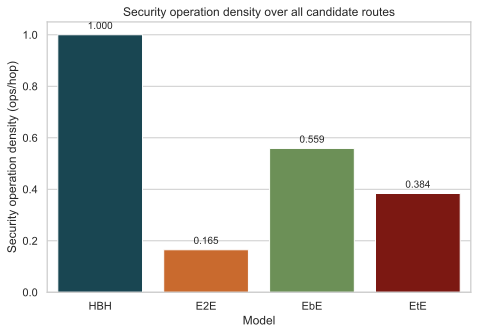

In [ ]:
rows = []

for sec_model in SecurityModelType:
    total_operations = 0
    total_hops = 0
    candidate_routes = 0

    for pair in result.security.pairs:
        annotated_routes = result.annotation.annotated_routes_by_pair[pair]
        protection_plans = result.security.plans_by_model[sec_model][pair]

        for annotated_route, plan in zip(annotated_routes, protection_plans, strict=True):
            total_operations += len(plan.operations)
            total_hops += len(annotated_route.hops)
            candidate_routes += 1

    rows.append(
        {
            "model": sec_model.name,
            "candidate_routes": candidate_routes,
            "security_operation_density_per_hop": (
                total_operations / total_hops if total_hops else 0.0
            ),
        }
    )

df_all_candidate_route_ops_density = pd.DataFrame(rows)
df_all_candidate_route_ops_density["model"] = format_model_series(
    df_all_candidate_route_ops_density["model"]
)

plot_df = df_all_candidate_route_ops_density.sort_values("model").reset_index(drop=True)

set_plot_theme()
fig, ax = plt.subplots(figsize=(6.8, 4.8))

sns.barplot(
    data=plot_df,
    x="model",
    y="security_operation_density_per_hop",
    order=MODEL_DISPLAY_ORDER,
    hue="model",
    hue_order=MODEL_DISPLAY_ORDER,
    palette=MODEL_PALETTE,
    dodge=False,
    legend=False,
    ax=ax,
)

ax.set_xlabel("Model")
ax.set_ylabel("Security operation density (ops/hop)")
ax.set_title("Security operation density over all candidate routes")
ax.set_ylim(0, 1.05)

for bar, row in zip(ax.patches, plot_df.itertuples(index=False), strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{row.security_operation_density_per_hop:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

fig.tight_layout()
fig.show()

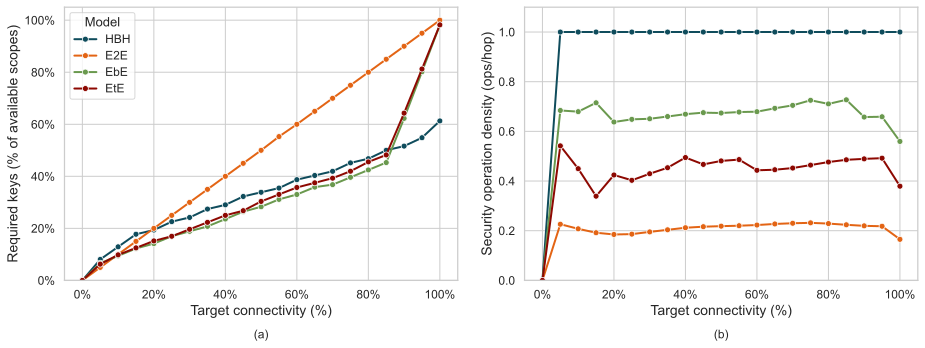

In [14]:
# WiSEE plot
set_plot_theme()

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13.4, 5))

plot_metric_curve(
    df_m2_paper,
    x="target_connectivity_pct",
    y="selected_keys_pct_of_available",
    ax=ax_left,
    sort_by="target_connectivity_pct",
    palette=palette_for(df_m2_paper["model"]),
    x_percent_scale=100,
    y_percent_scale=100,
    x_label="Target connectivity (%)",
    y_label="Required keys (% of available scopes)",
)

plot_metric_curve(
    df_m2_route_ops_hop_weighted,
    x="target_connectivity_pct",
    y="hop_weighted_security_operation_density_per_hop",
    ax=ax_right,
    sort_by="target_connectivity_pct",
    palette=palette_for(df_m2_route_ops_hop_weighted["model"]),
    x_percent_scale=100,
    x_label="Target connectivity (%)",
    y_label="Security operation density (ops/hop)",
)

ax_left.set_ylim(0, 105)
ax_right.set_ylim(0, 1.1)

for ax in (ax_left, ax_right):
    ax.set_title("")
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    ax.tick_params(axis="both", labelsize=12)

left_legend = ax_left.get_legend()
if left_legend is not None:
    left_legend.set_title("Model")
    left_legend.get_title().set_fontsize(13)
    for text in left_legend.get_texts():
        text.set_fontsize(12)

right_legend = ax_right.get_legend()
if right_legend is not None:
    right_legend.remove()

ax_left.text(
    0.5,
    -0.18,
    "(a)",
    transform=ax_left.transAxes,
    ha="center",
    va="top",
    fontsize=12,
)
ax_right.text(
    0.5,
    -0.18,
    "(b)",
    transform=ax_right.transAxes,
    ha="center",
    va="top",
    fontsize=12,
)

fig.subplots_adjust(left=0.11, right=0.995, bottom=0.22, top=0.98, wspace=0.17)
save_paper_figure(
    fig,
    "model2_fpp_required_key_share_and_security_operation_density_vs_connectivity",
)

In [15]:
# CALCULATIONS Trade-off plane from workspace pipeline outputs (no hardcoded paper values)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from modules.security.models import SecurityModelType
from models.model2_min_keys import solve_for_security_model
from models.plot_utils import (
    MODEL_DISPLAY_ORDER,
    MODEL_PALETTE,
    format_model_label,
    set_plot_theme,
)

TARGET_CONNECTIVITIES = [25, 50, 75, 100]
FOCUS_TOPOLOGY = None  # set this only if you want one entry from `all_pair_results`

if "result" in globals():
    focus_result = result
elif "sim_result" in globals():
    focus_result = sim_result
elif "all_pair_results" in globals():
    if FOCUS_TOPOLOGY is None:
        if len(all_pair_results) != 1:
            raise ValueError("Set FOCUS_TOPOLOGY because `all_pair_results` has more than one entry.")
        focus_result = next(iter(all_pair_results.values()))
    else:
        focus_result = all_pair_results[FOCUS_TOPOLOGY]
else:
    raise ValueError("Need `result`, `sim_result`, or `all_pair_results` in the notebook.")

def mean_selected_route_ops_per_hop(trace):
    if trace is None or not trace.routes:
        return 0.0
    per_route = [
        len(route.operations) / len(route.contacts)
        for route in trace.routes
        if route.contacts
    ]
    return float(np.mean(per_route)) if per_route else 0.0

def mean_data_at_rest_exposure_pct(trace):
    """
    Same proxy already explored in four_planes.ipynb:
    active intermediate security nodes / total intermediate nodes,
    averaged per selected route.
    """
    if trace is None or not trace.routes:
        return 0.0

    per_route = []
    for route in trace.routes:
        total_intermediate = max(len(route.node_path) - 2, 0)
        if total_intermediate == 0:
            continue

        active_intermediate = {
            node_id
            for op in route.operations
            for node_id in (op.source_node, op.acceptor_node)
            if node_id not in {route.pair[0], route.pair[1]}
        }
        per_route.append(100.0 * len(active_intermediate) / total_intermediate)

    return float(np.mean(per_route)) if per_route else 0.0

rows = []
sweep_by_model = {}
traces_by_model = {}

for sec_model in SecurityModelType:
    traces, sec_df = solve_for_security_model(focus_result, sec_model)
    sec_df = sec_df.copy()
    label = format_model_label(sec_model)

    sweep_by_model[label] = sec_df.set_index("target_connectivity_pct")
    traces_by_model[label] = {
        int(target): trace
        for target, trace in zip(sec_df["target_connectivity_pct"], traces, strict=True)
    }

    for target in TARGET_CONNECTIVITIES:
        if target not in sweep_by_model[label].index:
            continue

        point = sweep_by_model[label].loc[target]
        trace = traces_by_model[label].get(target)

        rows.append(
            {
                "model": label,
                "target_connectivity_pct": int(target),
                "active_key_scopes": int(point["selected_keys"]),
                "required_key_share_pct": float(point["selected_keys_pct_of_available"]),
                "data_at_rest_exposure_pct": mean_data_at_rest_exposure_pct(trace),
                "ops_per_hop": mean_selected_route_ops_per_hop(trace),
                "selected_routes": int(point["selected_routes"]),
                "selected_pairs": int(point["selected_pairs"]),
            }
        )

tradeoff_df = pd.DataFrame(rows)
tradeoff_df["model"] = pd.Categorical(
    tradeoff_df["model"],
    categories=MODEL_DISPLAY_ORDER,
    ordered=True,
)
tradeoff_df = tradeoff_df.sort_values(["model", "target_connectivity_pct"]).reset_index(drop=True)

display(tradeoff_df.round(3))



,model,target_connectivity_pct,active_key_scopes,required_key_share_pct,data_at_rest_exposure_pct,ops_per_hop,selected_routes,selected_pairs
0,HBH,25,14,22.581,100.000,1.000,95,95
1,HBH,50,21,33.871,100.000,1.000,190,190
2,HBH,75,28,45.161,100.000,1.000,286,286
3,HBH,100,38,61.290,100.000,1.000,380,380
4,E2E,25,95,25.000,0.000,0.318,95,95
5,E2E,50,190,50.000,0.000,0.348,190,190
6,E2E,75,285,75.000,0.000,0.358,285,285
7,E2E,100,380,100.000,0.000,0.228,1134,380
8,EbE,25,18,16.981,59.839,0.701,101,101
9,EbE,50,30,28.302,63.368,0.726,193,192


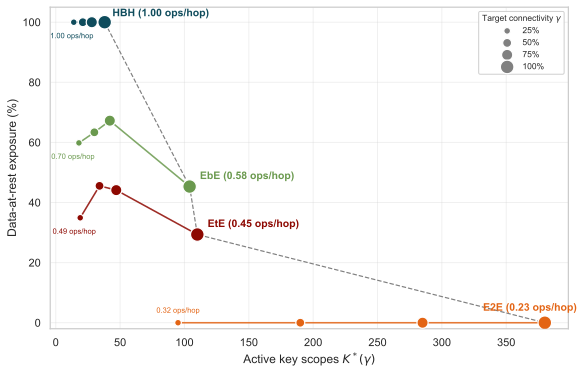

In [16]:
# PLOTTING Trade-off plane from workspace pipeline outputs (no hardcoded paper values)
set_plot_theme()
fig, ax = plt.subplots(figsize=(8.4, 5.4))

size_map = {25: 45, 50: 80, 75: 125, 100: 185}
label_offset = {"HBH": (6, 2), "EbE": (8, 2.5), "EtE": (8, 2.5), "E2E": (-48, 4)}
ops_offset = {"HBH": (-2, -16), "EbE": (-6, -16), "EtE": (-6, -16), "E2E": (0, 10)}

frontier = []

for model in MODEL_DISPLAY_ORDER:
    model_df = tradeoff_df[tradeoff_df["model"] == model]
    if model_df.empty:
        continue

    color = MODEL_PALETTE[model]
    x = model_df["active_key_scopes"].to_numpy()
    y = model_df["data_at_rest_exposure_pct"].to_numpy()
    sizes = [size_map[int(v)] for v in model_df["target_connectivity_pct"]]

    ax.plot(x, y, "-", color=color, lw=1.6, alpha=0.85, zorder=2)
    ax.scatter(x, y, s=sizes, color=color, edgecolor="white", lw=1.2, zorder=3)

    first = model_df.iloc[0]
    last = model_df.iloc[-1]

    ox, oy = ops_offset.get(model, (0, -16))
    ax.annotate(
        f"{first.ops_per_hop:.2f} ops/hop",
        (first.active_key_scopes, first.data_at_rest_exposure_pct),
        textcoords="offset points",
        xytext=(ox, oy),
        ha="center",
        fontsize=7.5,
        color=color,
    )

    dx, dy = label_offset.get(model, (8, 2))
    ax.annotate(
        f"{model} ({last.ops_per_hop:.2f} ops/hop)",
        (last.active_key_scopes + dx, last.data_at_rest_exposure_pct + dy),
        fontsize=10.5,
        fontweight="bold",
        color=color,
    )

    endpoint = model_df[model_df["target_connectivity_pct"] == 100]
    if not endpoint.empty:
        endpoint = endpoint.iloc[0]
        frontier.append((endpoint["active_key_scopes"], endpoint["data_at_rest_exposure_pct"]))

if frontier:
    frontier = sorted(frontier)
    fx, fy = zip(*frontier)
    ax.plot(fx, fy, "--", color="gray", lw=1.2, zorder=1)

legend_handles = [
    ax.scatter([], [], s=s, color="gray", edgecolor="white", lw=1.2)
    for s in [45, 80, 125, 185]
]
ax.legend(
    legend_handles,
    ["25%", "50%", "75%", "100%"],
    title="Target connectivity $\\gamma$",
    loc="upper right",
    fontsize=8.5,
    title_fontsize=8.5,
    framealpha=0.95,
)

ax.set_xlabel("Active key scopes $K^*(\\gamma)$")
ax.set_ylabel("Data-at-rest exposure (%)")
ax.set_ylim(-2, 105)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
save_paper_figure(
    fig,
    "model2_fpp_full_tradeoff_scatter_plot",
)

In [17]:
import math

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap

from models.plot_utils import (
    MODEL_PALETTE,
    build_key_scope_activation_data,
    format_model_label,
    set_plot_theme,
)


def _key_scope_sort_key(label: str):
    key_type_order = {"N-N": 0, "N-G": 1, "G-G": 2}
    try:
        key_type, endpoints = label.split(" ", 1)
        src, dst = endpoints.split("->", 1)
        return (key_type_order.get(key_type, 99), int(src), int(dst), label)
    except Exception:
        return (99, math.inf, math.inf, label)


def plot_active_key_heatmaps_by_scheme(
    traces_by_scheme,
    connectivity_min=60,
    connectivity_max=100,
    schemes=None,
):
    set_plot_theme()

    schemes = list(schemes or traces_by_scheme.keys())
    filtered_by_scheme = {
        scheme: {
            pct: trace
            for pct, trace in sorted(traces_by_scheme[scheme].items())
            if connectivity_min <= pct <= connectivity_max
        }
        for scheme in schemes
    }

    valid_schemes = [scheme for scheme, traces in filtered_by_scheme.items() if traces]
    if not valid_schemes:
        raise ValueError("No hay targets de conectividad dentro del rango pedido.")

    pivots = {}
    for scheme in valid_schemes:
        data = build_key_scope_activation_data(
            filtered_by_scheme[scheme],
            sweep_label="target_connectivity_pct",
        )

        x_order = list(filtered_by_scheme[scheme].keys())
        if data.empty:
            pivots[scheme] = pd.DataFrame(columns=x_order)
            continue

        pivot = (
            data.pivot_table(
                index="key_scope",
                columns="target_connectivity_pct",
                values="selected",
                aggfunc="sum",
                fill_value=0,
            )
            .reindex(columns=x_order, fill_value=0)
            .sort_index(key=lambda idx: idx.map(_key_scope_sort_key))
        )

        # Solo deja las keys que estuvieron activas al menos una vez en el rango.
        pivot = pivot.loc[pivot.sum(axis=1) > 0]
        pivots[scheme] = pivot

    height_ratios = [max(2.4, 0.32 * max(len(pivot), 1)) for pivot in pivots.values()]
    fig, axes = plt.subplots(
        nrows=len(valid_schemes),
        ncols=1,
        figsize=(12, sum(height_ratios) + 0.8 * len(valid_schemes)),
        gridspec_kw={"height_ratios": height_ratios},
        constrained_layout=True,
    )

    if len(valid_schemes) == 1:
        axes = [axes]

    for ax, scheme in zip(axes, valid_schemes, strict=True):
        pivot = pivots[scheme]
        color = MODEL_PALETTE.get(format_model_label(scheme), "#e36414")
        cmap = ListedColormap(["#f4f7fb", color])

        if pivot.empty:
            ax.axis("off")
            ax.set_title(f"{format_model_label(scheme)}: no active keys in range")
            continue

        sns.heatmap(
            pivot,
            ax=ax,
            cmap=cmap,
            cbar=False,
            vmin=0,
            vmax=1,
            linewidths=0.3,
            linecolor="#ffffff",
        )

        ax.set_title(f"{format_model_label(scheme)} | Active keys by target connectivity")
        ax.set_xlabel("Target connectivity (%)")
        ax.set_ylabel("Key scope")
        ax.set_xticklabels([f"{int(value)}%" for value in pivot.columns], rotation=0)
        ax.tick_params(axis="y", labelsize=9)

    return fig, axes


# Ejemplo
fig, axes = plot_active_key_heatmaps_by_scheme(
    traces_m2,
    connectivity_min=60,
    connectivity_max=100,
)
save_paper_figure(
    fig,
    "fpp_activated_keys",
)
plt.show()


<Axes: title={'center': 'Required keys at 100% connectivity'}, xlabel='Model', ylabel='Required keys (% of available scopes)'>

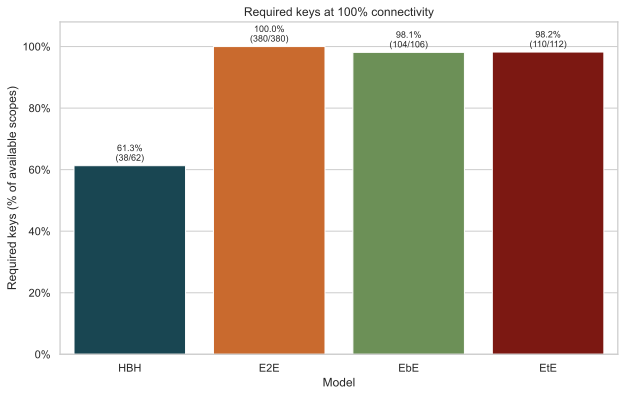

In [18]:
from models.model2_min_keys import plot_required_key_percentage_at_connectivity

plot_required_key_percentage_at_connectivity(
    df_m2,
    target_connectivity_pct=100,
)